# Interpreting models and feature importance

Machine learning models are primarily concerned with one thing - given a set of inputs, can we predict the output. Most of the problems you have been studying are of the form "Given a set of gene expression levels, or a set of DNA mutations, can I predict the cancer subtype?". In general, an ML model is not concerned with *why* a particularly example should be classificed as category A or B, just that it should. 

However, there are several methods that we can use to look into why a model is making the decisions it is, and if used carefully, and with the correct caveats, can tell us something about what is going on.

## Feature coefficients in a logistic regression

Recall that in a logistic regression model we calculate

$$ z = \beta_1 x_1 + \beta_2 x_2 + .... + \beta_m x_m $$
$$ Y = \frac{x}{1-e^{-z}} $$

the model finds the best values for the $\beta$s, so these values can tell us how much the model is using each predictive value to make its prediction. Lets return to our breast cancer prediction model:

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd

X, Y = load_breast_cancer(return_X_y=True, as_frame=True)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
scaler = StandardScaler().fit(X_train)
scaled_X_train = scaler.transform(X_train)

LR_model = LogisticRegression(random_state=1, max_iter=10000, penalty=None, solver="saga")
LR_model = LR_model.fit(scaled_X_train, Y_train)
y_train_pred = LR_model.predict(scaled_X_train)
y_test_pred = LR_model.predict(scaler.transform(X_test))
print(f"F1 score on training data: {f1_score(Y_train, y_train_pred)}")
print(f"F1 score on test data: {f1_score(Y_test, y_test_pred)}")

/home/mb1ims/mambaforge/envs/bis312-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


F1 score on training data: 0.9930795847750865
F1 score on test data: 0.9402985074626866


We can extract the values for the chosen $\beta$s using `model.coef_`:

In [40]:
LR_model.coef_

array([[-0.14748117,  0.33393975, -0.06164795, -1.53253157, -0.16234622,
         6.81868629, -0.82107259, -6.55811011,  1.4483076 ,  0.39429706,
        -4.97128937, -0.65172964, -2.03834344, -6.11448037, -0.37469714,
         0.0332825 ,  0.59236434, -3.38559538,  0.40233525,  6.66348377,
        -3.08943848, -2.76120002, -2.90625824, -5.06925521, -3.5609715 ,
        -0.52851945, -3.15391235,  2.22458189, -1.74949521, -5.70638907]])

We can make that a bit more readable with by making a dataframe with the feature names

In [5]:
import pandas as pd
coeffients = pd.DataFrame(LR_model.coef_[0], columns=["Coefficient"], index=scaler.feature_names_in_)
coeffients

,Coefficient
mean radius,-0.147481
mean texture,0.333940
mean perimeter,-0.061648
mean area,-1.532532
mean smoothness,-0.162346
mean compactness,6.818686
mean concavity,-0.821073
mean concave points,-6.558110
mean symmetry,1.448308
mean fractal dimension,0.394297


We can even make a plot of this:

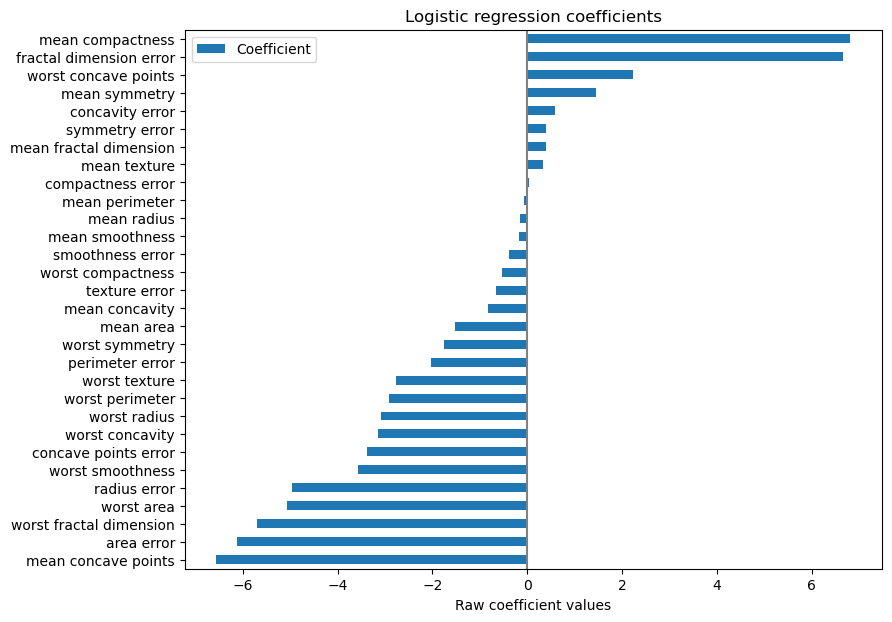

In [6]:
import matplotlib.pyplot as plt
coeffients.sort_values(by="Coefficient").plot.barh(figsize=(9, 7))
plt.title("Logistic regression coefficients")
plt.axvline(x=0, color=".5")
_ = plt.xlabel("Raw coefficient values")

Remembering that we transformed the features going in, this mean that for every standard deviation that the mean compactness increaes, the value of z is increased by 6, and for every standard deviation that "mean concave points" increased, the value of z decreases by 6.

This interpretation might be different if, for example, you are using gene expression data, or you have not scaled your data. For example, if you are using unscaled, but log transformed gene expression data, then a coefficient of 1 means that for every doubling in expression, you will see an increase of 1 in z. This makes genes comparable, where as without the log transformation, an increase of 1 molecule in a gene that usually has 10 molecules per cell is not the same as a 1 molecule increase in a gene that usually has 10,000 molecules per cell. You should think very carefully about how your preprocessing affects your interpretation - you should be particularly wary if the data is not preprocessed at all. 

We can also look to see how dependent the exact coefficient values are on precise data supplied - does a small change in data lead to large change in coefficients? 

We can test this using cross-validation. 

/home/mb1ims/.local/share/mamba/envs/bis312-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


F1 score on training data: 0.9930795847750865
F1 score on test data: 0.9402985074626866


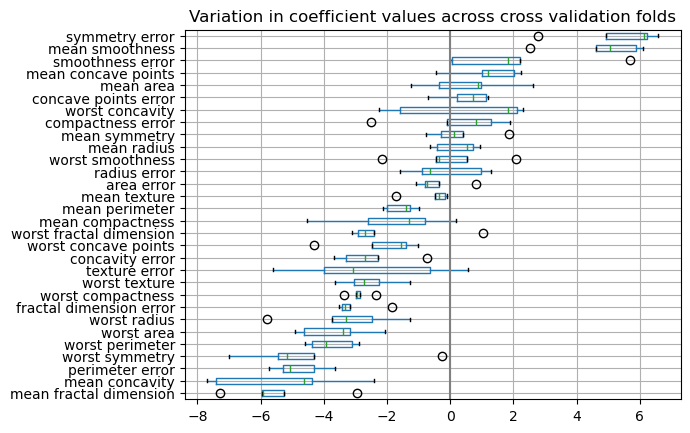

In [70]:
LR_cv = LogisticRegressionCV(max_iter=10000, Cs=(np.inf,), l1_ratios=(0.0,), random_state=2, solver="saga")
LR_cv = LR_cv.fit(scaled_X_train, Y_train)
y_train_pred = LR_cv.predict(scaled_X_train)
y_test_pred = LR_cv.predict(scaler.transform(X_test))
print(f"F1 score on training data: {f1_score(Y_train, y_train_pred)}")
print(f"F1 score on test data: {f1_score(Y_test, y_test_pred)}")

coefs = pd.DataFrame(LR_cv.coefs_paths_[1][:,0,0,1:], columns=scaler.feature_names_in_)

# No need to worry how this plotting code works
column_order = coefs.mean().sort_values().index
coefs.reindex(column_order, axis=1).boxplot(vert=False)
plt.title("Variation in coefficient values across cross validation folds")
plt.axvline(x=0, color=".5")

Some of these coefficient values vary quite a lot from fold to fold. This could either be due to over-fitting to the data in each fold, or it could be due to correlated variables. That is there are multiple variables giving the same information to the model - if it uses one, it doesn't need to use another. This is a big issue with gene expression, because lots of genes are correlated with each other. Just think that if a transcript factor is activated, all of its downstream targets will be activated. 

This is another place were regulariation comes in useful, as it deals with correlated variables. The two different types of regularisation deal with it in different ways, as we'll see. Lets start with ridge:

F1 score on training data: 0.9879518072289156
F1 score on test data: 0.9787234042553191


/home/mb1ims/.local/share/mamba/envs/bis312-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


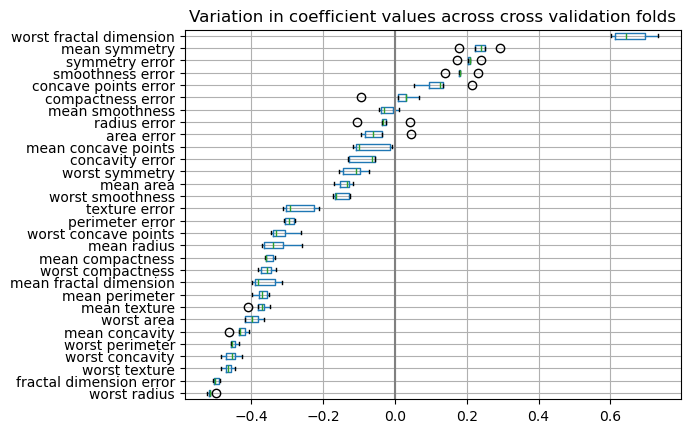

In [71]:
LR_cv = LogisticRegressionCV(max_iter=10000, Cs=(0.1,), l1_ratios=(0.0,), random_state=2, solver="saga")
LR_cv = LR_cv.fit(scaled_X_train, Y_train)

y_train_pred = LR_cv.predict(scaled_X_train)
y_test_pred = LR_cv.predict(scaler.transform(X_test))
print(f"F1 score on training data: {f1_score(Y_train, y_train_pred)}")
print(f"F1 score on test data: {f1_score(Y_test, y_test_pred)}")

coefs = pd.DataFrame(LR_cv.coefs_paths_[1][:,0,0,1:], columns=scaler.feature_names_in_)

# No need to worry how this plotting code works
column_order = coefs.mean().sort_values().index
coefs.reindex(column_order, axis=1).boxplot(vert=False)
plt.title("Variation in coefficient values across cross validation folds")
plt.axvline(x=0, color=".5")

The variation is much reduced. Ridge takes the signal associated with correlated features, and spreads it out across all the correlated features. So instead of feature 1=10, feature 2=1 on one fold, and feature 1=1, feature 2 =10 in a second fold, you get something more like feature 1=3, feature 2=3. 

On the other hand lasso tends to pick on feature out of a set of correlated features:

/home/mb1ims/.local/share/mamba/envs/bis312-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


F1 score on training data: 0.9761092150170648
F1 score on test data: 0.9787234042553191


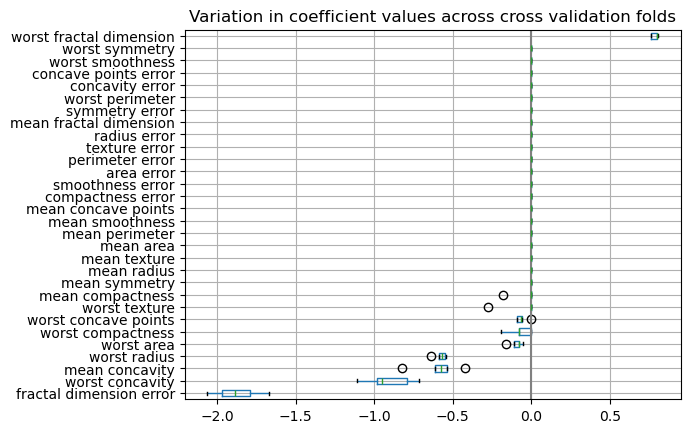

In [72]:
LR_cv = LogisticRegressionCV(max_iter=10000, Cs=(0.1,), l1_ratios=(1.0,), random_state=2, solver="saga")
LR_cv = LR_cv.fit(scaled_X_train, Y_train)

y_train_pred = LR_cv.predict(scaled_X_train)
y_test_pred = LR_cv.predict(scaler.transform(X_test))
print(f"F1 score on training data: {f1_score(Y_train, y_train_pred)}")
print(f"F1 score on test data: {f1_score(Y_test, y_test_pred)}")

coefs = pd.DataFrame(LR_cv.coefs_paths_[1][:,0,0,1:], columns=scaler.feature_names_in_)

# No need to worry how this plotting code works
column_order = coefs.mean().sort_values().index
coefs.reindex(column_order, axis=1).boxplot(vert=False)
plt.title("Variation in coefficient values across cross validation folds")
plt.axvline(x=0, color=".5")

Here you can see that most of the coefficients are (close to zero), and only really 7 are selected with "fractal dimension error" (whatever that is) being the most influential. 

So the two regularization models deliver similar perforamnces on the test set, but with very different sets of coefficients. This should tell you immediately that there is no one true "correct" set of coefficients, and that its dangerous to interpret coefficients from the model as indicative of causation. 

These are correlations, not causations. But it can point in towards interesting areas of biology. 

Read more here: https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html and here: https://scikit-learn.org/stable/auto_examples/inspection/plot_causal_interpretation.html


## Feature importance in tree models

There are two basic ways to measure feature importance in tree models. The first is called mean decrease in impurity (MDI). Imagine that you have a collection samples from two classes and you split them in two using some feature. You can measure how "pure" the starting pool is (i.e. what fraction come from a single class), and then how pure each of the two pools you split it into are. If the feature an important one, the resulting two pools should be more pure than the starting pool. i.e. there has been a decrase in impurity. 

F1 score on training data: 0.9930795847750865
F1 score on test data: 0.9402985074626866


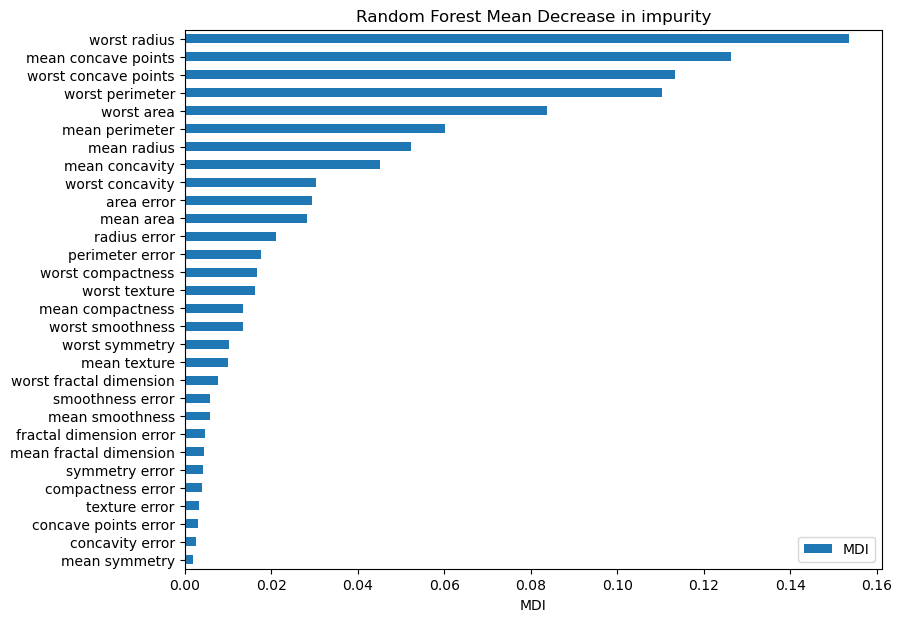

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf = rf.fit(X_train, Y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print(f"F1 score on training data: {f1_score(Y_train, y_train_pred)}")
print(f"F1 score on test data: {f1_score(Y_test, y_test_pred)}")

feature_importance = pd.DataFrame(rf.feature_importances_, columns=["MDI"], index=X_train.columns)
feature_importance.sort_values(by="MDI").plot.barh(figsize=(9, 7))
plt.title("Random Forest Mean Decrease in impurity")
plt.axvline(x=0, color=".5")
_ = plt.xlabel("MDI")

Note that MDI scores are always positive as they measure the importance, not the direction of the effect. MDI is one way of measure the importance of features. It suffers from a weakness, which is that higher "cardinality" features get more weight. A higher cardianlity feature is one that can take more values, a bit like coefficients in linear models. 

An alternative is "feature permutation". Here a model is fit, and then the values of one of the features is shuffled, the results are re-predicted. We can them measure how less accurate the model now fits. The bigger the difference, the more important the feature. 

We do this using the `permutation importance` function:

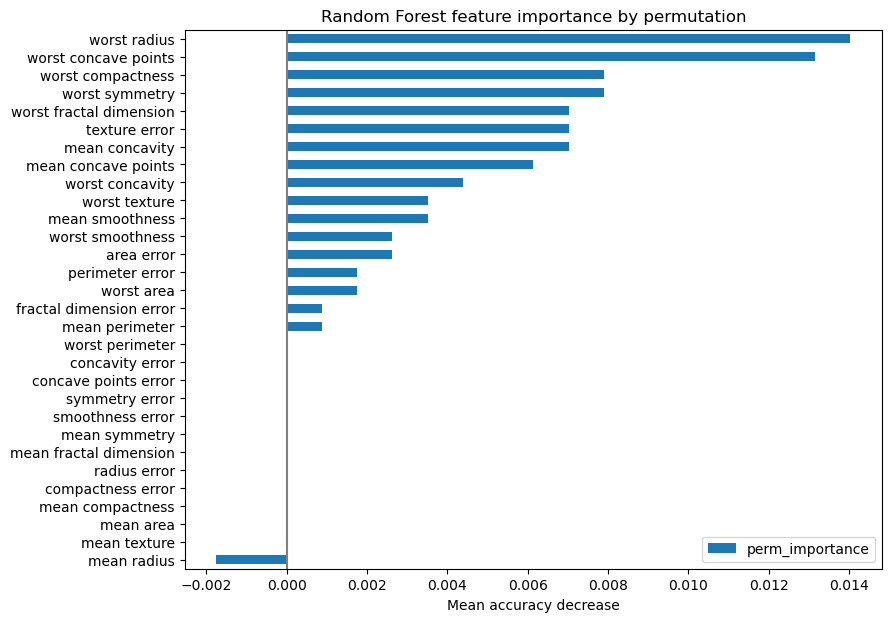

In [11]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test, Y_test, n_repeats=10, random_state=2, n_jobs=2
)

perm_importance = pd.DataFrame(result.importances_mean, columns=["perm_importance"], index=X_test.columns)
perm_importance.sort_values(by="perm_importance").plot.barh(figsize=(9, 7))
plt.title("Random Forest feature importance by permutation")
plt.axvline(x=0, color=".5")
_ = plt.xlabel("Mean accuracy decrease")

The advantages of permutation importance are that they do not suffer from the "cardinality" issue. They are also run on test data (or more properly vaidation data), rather than the training data, so they don't tell you features your model as overfit on. The downside is that they suffer from correlated data. Imagine you had two figures that are perfectly correlated. If you shuffle one, the model can still use the other to do the classification. 
